In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import LlamaForCausalLM
from loguru import logger
from pjs.dataset import Data
import itertools

df = pd.read_csv('../data/results/outlines_data_results.csv')

df['ShortFile'] = df['File'].str.replace('.csv', '', regex=False)

metric_cols = ['Accuracy']

/home/laurens/.cache/pypoetry/virtualenvs/pjs-QokBllAi-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


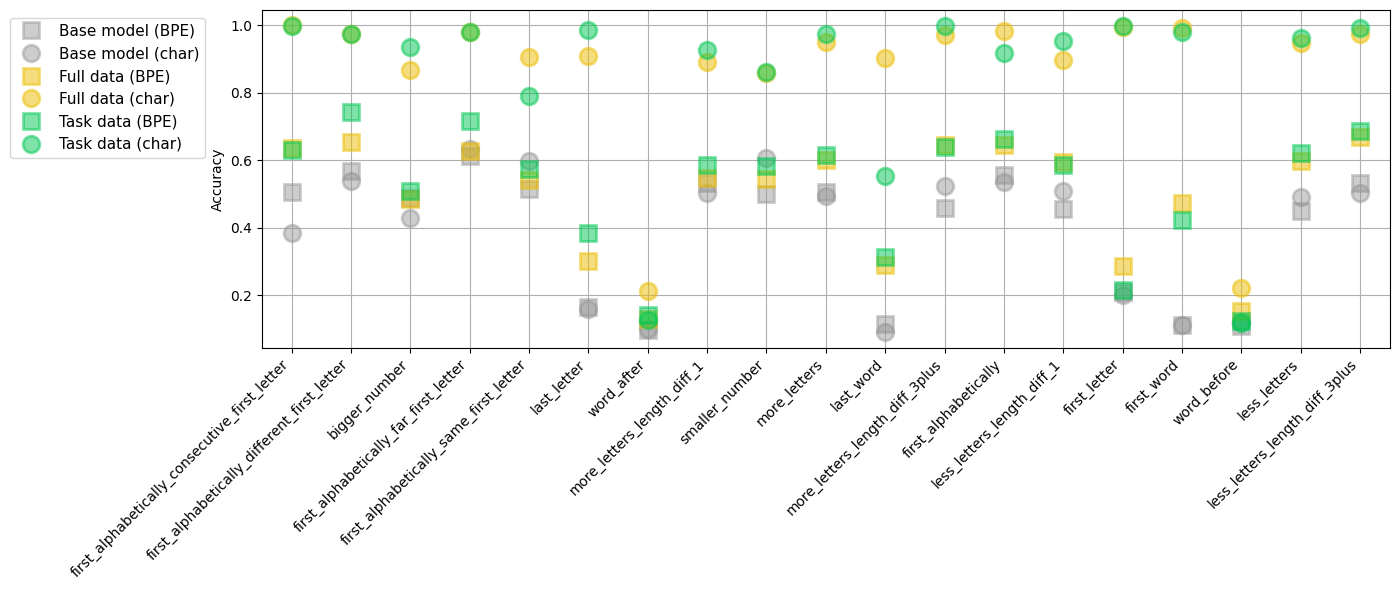

In [2]:
melted = df.melt(id_vars=['ShortFile', 'Subfolder'], 
                 value_vars=metric_cols,
                 var_name='Metrik', 
                 value_name='Wert')

metrics = ['Accuracy']

melted_de = melted[melted['Subfolder'].str.contains('_de', na=False)]

markers = ["s", "o", "s", "o", "s", "o"]
colors  = ["#94949475", "#94949475", "#ecbd0080",
           "#ecbd0080", "#00c75380", "#00c75380"]
marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)

for metric in metrics:
    subset = melted_de[melted_de['Metrik'] == metric]

    plt.figure(figsize=(14, 6))

    for subfolder, data in subset.groupby("Subfolder"):
        if not subfolder.startswith("baseline_"):
            marker = next(marker_cycle)
            color = next(color_cycle)

            parts = [x for x in subfolder.split("_") if x not in ("de", "train")]

            if parts:
                last = parts[-1]
                if last.lower() == "bpe":
                    last = last.upper()
                else:
                    last = last.lower()
                label = " ".join(parts[:-1] + [f"({last})"])
                label = label[0].upper() + label[1:]
            else:
                label = ""

            sns.pointplot(
                data=data,
                x="ShortFile",
                y="Wert",
                label=label,
                markers=marker,
                linestyles="",
                color = color,
                errorbar=None,
                markersize=12
            )

    plt.xlabel("")
    plt.ylabel(metric)
    plt.legend(
        bbox_to_anchor=(-0.23, 1),
        loc="upper left",
        fontsize=11,
        markerscale=1
    )

    plt.xticks(rotation=45, ha="right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"../data/results/{metric}_de_point.pdf", format="pdf", bbox_inches="tight")
    plt.show()


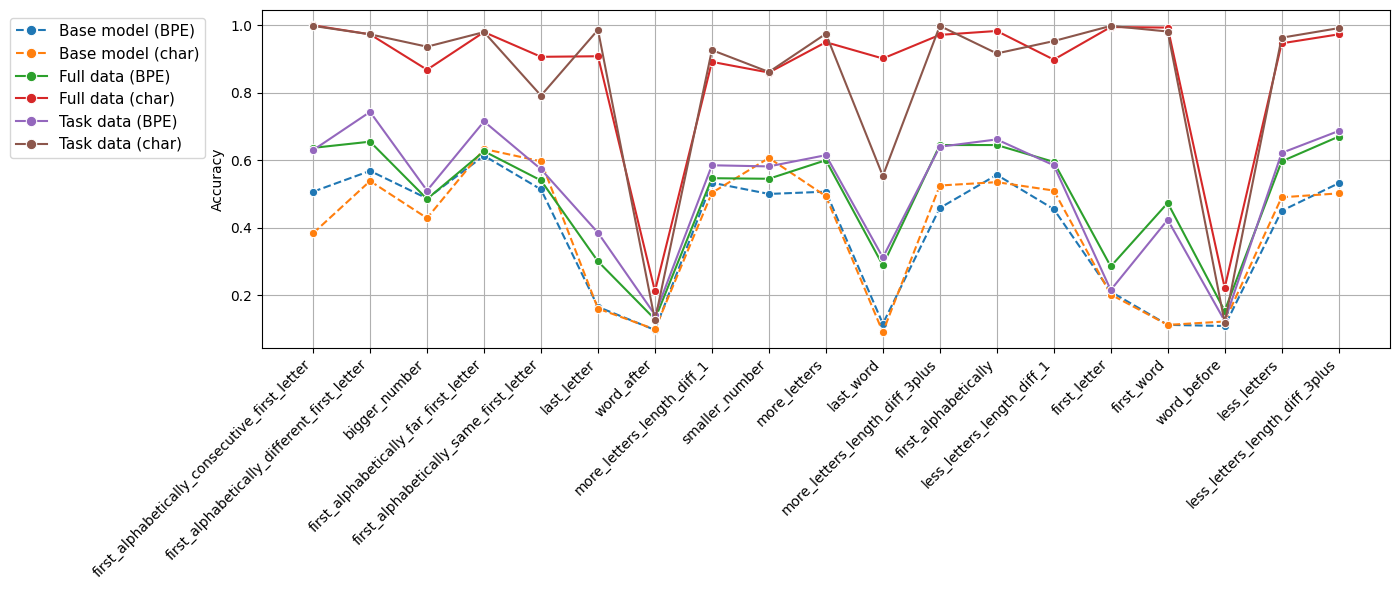

In [9]:
melted = df.melt(id_vars=['ShortFile', 'Subfolder'], 
                 value_vars=metric_cols,
                 var_name='Metrik', 
                 value_name='Wert')

metrics = ['Accuracy']

melted_de = melted[melted['Subfolder'].str.contains('_de', na=False)]

for metric in metrics:
    subset = melted_de[melted_de['Metrik'] == metric]
    
    plt.figure(figsize=(14, 6))
    
    # Subfolder durchgehen und jeweils plotten
    for subfolder, data in subset.groupby("Subfolder"):
        if not subfolder.startswith("baseline_"):
            linestyle = "--" if subfolder.startswith("base_") else "-"
            parts = [x for x in subfolder.split("_") if x not in ("de", "train")]

            if parts:
                last = parts[-1]
                if last.lower() == "bpe":
                    last = last.upper()
                else:
                    last = last.lower()
                subfolder = " ".join(parts[:-1] + [f"({last})"])
                subfolder = subfolder[0].upper() + subfolder[1:]  # erster Buchstabe groß
            else:
                subfolder = ""
            sns.lineplot(
                data=data,
                x="ShortFile",
                y="Wert",
                label=subfolder,
                marker="o",
                linestyle=linestyle
            )
    
    plt.xlabel("")
    plt.ylabel(metric) 
    # plt.title(f"{metric} über Modellvarianten hinweg zu jedem Task")
    plt.legend(bbox_to_anchor=(-0.23, 1), loc="upper left", fontsize=11, markerscale=1.25)
    
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)  # Gitter hinzufügen
    plt.tight_layout()
    plt.savefig(f"../data/results/{metric}_de.pdf", format="pdf", bbox_inches="tight")
    plt.show()



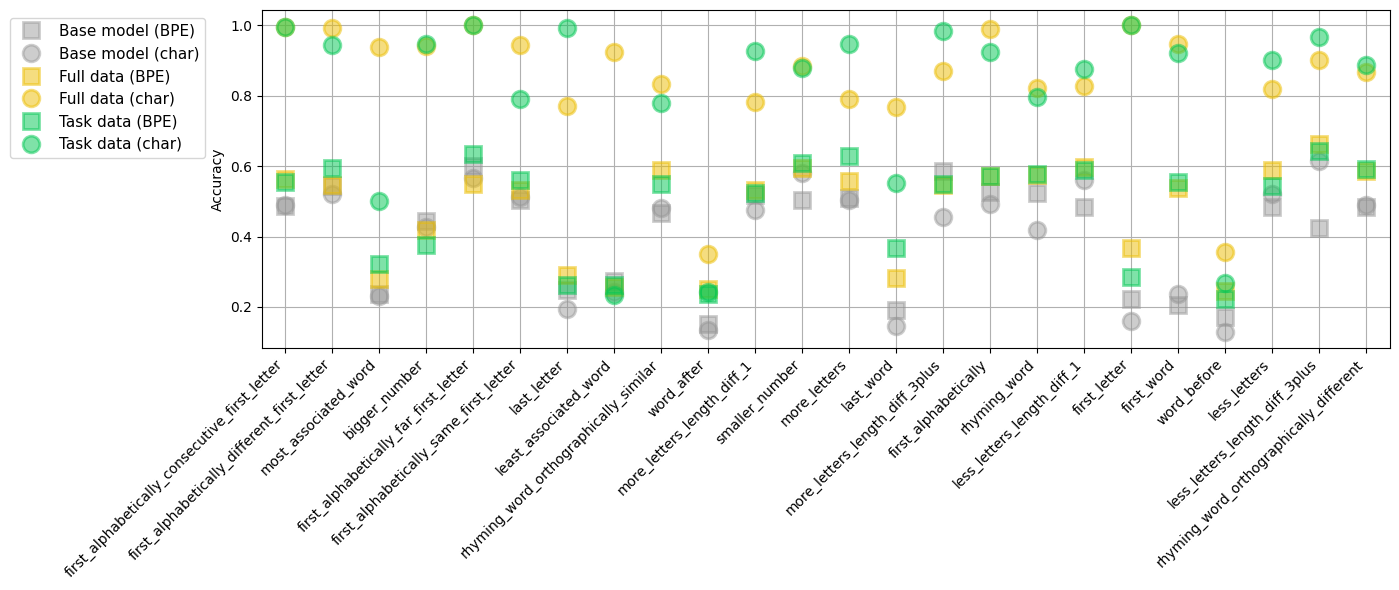

In [3]:
melted_en = melted[melted['Subfolder'].str.contains('_en', na=False)]

markers = ["s", "o", "s", "o", "s", "o"]
colors  = ["#94949475", "#94949475", "#ecbd0080",
           "#ecbd0080", "#00c75380", "#00c75380"]
marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)

for metric in metrics:
    subset = melted_en[melted_en['Metrik'] == metric]

    plt.figure(figsize=(14, 6))

    for subfolder, data in subset.groupby("Subfolder"):
        if not subfolder.startswith("baseline_"):
            marker = next(marker_cycle)
            color = next(color_cycle)

            parts = [x for x in subfolder.split("_") if x not in ("en", "train")]

            if parts:
                last = parts[-1]
                if last.lower() == "bpe":
                    last = last.upper()
                else:
                    last = last.lower()
                label = " ".join(parts[:-1] + [f"({last})"])
                label = label[0].upper() + label[1:]
            else:
                label = ""

            sns.pointplot(
                data=data,
                x="ShortFile",
                y="Wert",
                label=label,
                markers=marker,
                linestyles="",
                color = color,
                errorbar=None,
                markersize=12
            )

    plt.xlabel("")
    plt.ylabel(metric)
    plt.legend(
        bbox_to_anchor=(-0.23, 1),
        loc="upper left",
        fontsize=11,
        markerscale=1
    )

    plt.xticks(rotation=45, ha="right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"../data/results/{metric}_en_point.pdf", format="pdf", bbox_inches="tight")
    plt.show()

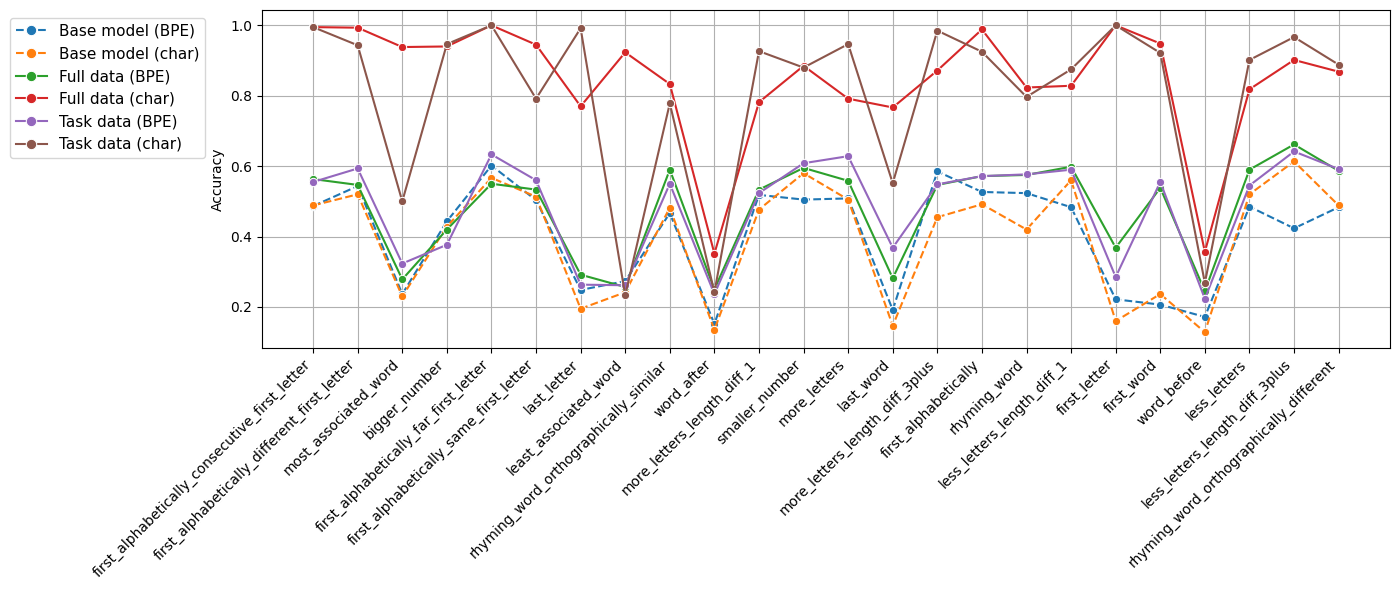

In [11]:
melted_en = melted[melted['Subfolder'].str.contains('_en', na=False)]

for metric in metrics:
    subset = melted_en[melted_en['Metrik'] == metric]
    
    plt.figure(figsize=(14, 6))
    
    # Subfolder durchgehen und jeweils plotten
    for subfolder, data in subset.groupby("Subfolder"):
        if not subfolder.startswith("baseline_"):
            linestyle = "--" if subfolder.startswith("base_") else "-"
            parts = [x for x in subfolder.split("_") if x not in ("en", "train")]

            if parts:
                last = parts[-1]
                if last.lower() == "bpe":
                    last = last.upper()
                else:
                    last = last.lower()
                subfolder = " ".join(parts[:-1] + [f"({last})"])
                subfolder = subfolder[0].upper() + subfolder[1:]  # erster Buchstabe groß
            else:
                subfolder = ""
            sns.lineplot(
                data=data,
                x="ShortFile",
                y="Wert",
                label=subfolder,
                marker="o",
                linestyle=linestyle
            )
    
    plt.xlabel("")
    plt.ylabel(metric) 
    # plt.title(f"{metric} über Modellvarianten hinweg zu jedem Task")
    plt.legend(bbox_to_anchor=(-0.23, 1), loc="upper left", fontsize=11, markerscale=1.25)
    
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)  # Gitter hinzufügen
    plt.tight_layout()
    plt.savefig(f"../data/results/{metric}_en.pdf", format="pdf", bbox_inches="tight")
    plt.show()


In [24]:

def model_size(model_path):
    model = LlamaForCausalLM.from_pretrained(model_path)
    return sum(p.numel() for p in model.parameters())


In [25]:
logger.info(f'DE Base Model BPE size: {model_size("../data/models/baby_lm_de_bpe/model/final")}')
logger.info(f'DE Base Model char size: {model_size("../data/models/baby_lm_de_char/model/final")}')
logger.info(f'EN Base Model BPE size: {model_size("../data/models/baby_lm_en_bpe/model/final")}')
logger.info(f'EN Base Model char size: {model_size("../data/models/baby_lm_en_char/model/final")}')

2025-10-06 17:55:57.915 | INFO     | __main__:<module>:1 - DE Base Model BPE size: 137841408
2025-10-06 17:55:57.934 | INFO     | __main__:<module>:2 - DE Base Model char size: 113382144
2025-10-06 17:55:57.953 | INFO     | __main__:<module>:3 - EN Base Model BPE size: 137841408
2025-10-06 17:55:57.971 | INFO     | __main__:<module>:4 - EN Base Model char size: 113382144


In [26]:
data = Data()
data.load_split("../data/dataset_splits/LMentry_de")
token_counts_de = data.get_token_count()

data.load_split("../data/dataset_splits/LMentry_en")
token_counts_en = data.get_token_count()


2025-10-06 17:55:58.054 | INFO     | pjs.dataset:load_split:147 - loaded split succesfully
2025-10-06 17:55:59.045 | INFO     | pjs.dataset:load_split:147 - loaded split succesfully


In [27]:
logger.info(f'The dataset contains {token_counts_de} tokens')
logger.info(f'The dataset contains {token_counts_en} tokens')

2025-10-06 17:56:00.121 | INFO     | __main__:<module>:1 - The dataset contains {'test_token_count': 150421, 'train_token_count': 599803, 'total_token_count': 750224} tokens
2025-10-06 17:56:00.122 | INFO     | __main__:<module>:2 - The dataset contains {'test_token_count': 204127, 'train_token_count': 816181, 'total_token_count': 1020308} tokens


In [28]:
df = pd.read_csv('../data/results/raw_data_results.csv')

df['ShortFile'] = df['File'].str.replace('.csv', '', regex=False)

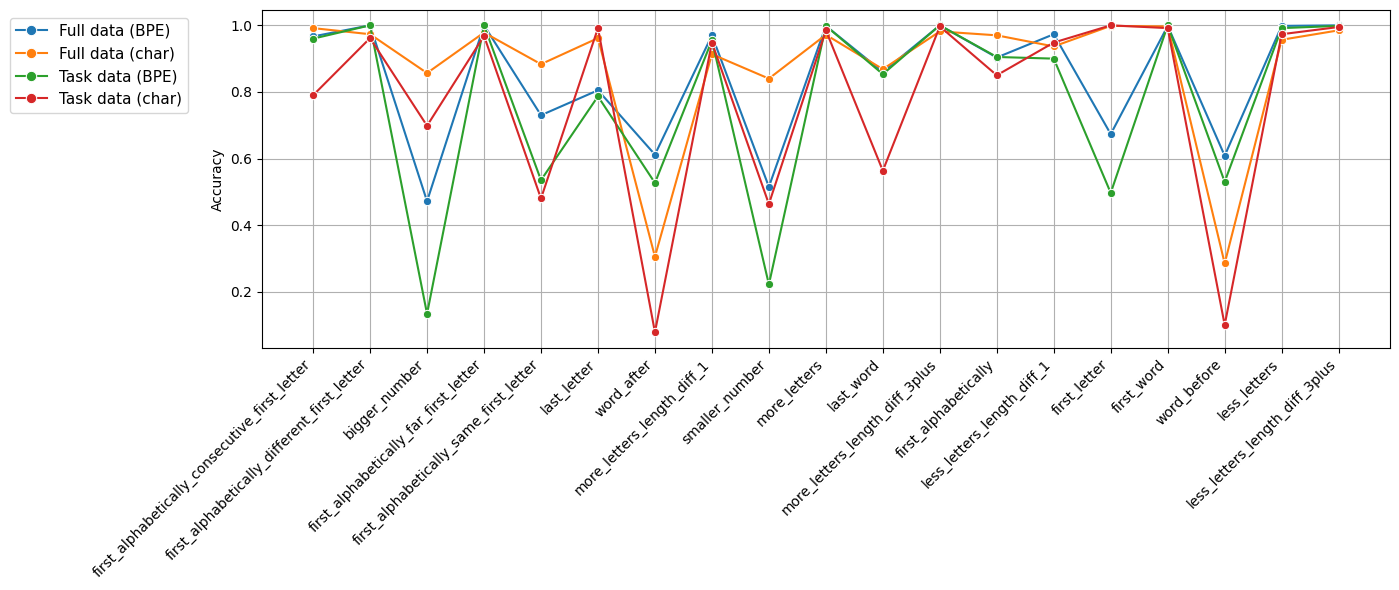

In [29]:
melted = df.melt(id_vars=['ShortFile', 'Subfolder'], 
                 value_vars=metric_cols,
                 var_name='Metrik', 
                 value_name='Wert')

melted_de = melted[melted['Subfolder'].str.contains('_de', na=False)]

for metric in metrics:
    subset = melted_de[melted_de['Metrik'] == metric]
    
    plt.figure(figsize=(14, 6))
    
    # Subfolder durchgehen und jeweils plotten
    for subfolder, data in subset.groupby("Subfolder"):
        if not subfolder.startswith("baseline_"):
            linestyle = "--" if subfolder.startswith("base_") else "-"
            parts = [x for x in subfolder.split("_") if x not in ("de", "train")]

            if parts:
                last = parts[-1]
                if last.lower() == "bpe":
                    last = last.upper()
                else:
                    last = last.lower()
                subfolder = " ".join(parts[:-1] + [f"({last})"])
                subfolder = subfolder[0].upper() + subfolder[1:]  # erster Buchstabe groß
            else:
                subfolder = ""
            sns.lineplot(
                data=data,
                x="ShortFile",
                y="Wert",
                label=subfolder,
                marker="o",
                linestyle=linestyle
            )
    
    plt.xlabel("")
    plt.ylabel(metric) 
    # plt.title(f"{metric} über Modellvarianten hinweg zu jedem Task")
    plt.legend(bbox_to_anchor=(-0.23, 1), loc="upper left", fontsize=11, markerscale=1.25)
    
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)  # Gitter hinzufügen
    plt.tight_layout()
    plt.savefig(f"../data/results/{metric}_raw_de.pdf", format="pdf", bbox_inches="tight")
    plt.show()

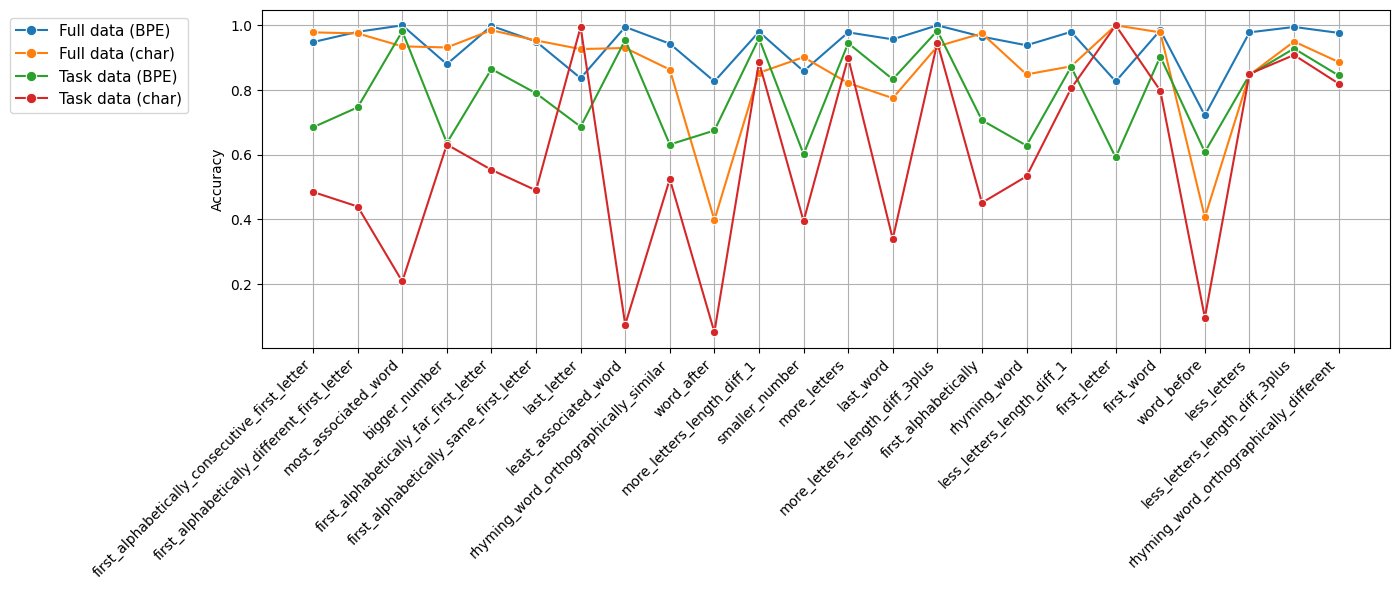

In [30]:
melted_en = melted[melted['Subfolder'].str.contains('_en', na=False)]

for metric in metrics:
    subset = melted_en[melted_en['Metrik'] == metric]
    
    plt.figure(figsize=(14, 6))
    
    # Subfolder durchgehen und jeweils plotten
    for subfolder, data in subset.groupby("Subfolder"):
        if not subfolder.startswith("baseline_"):
            linestyle = "--" if subfolder.startswith("base_") else "-"
            parts = [x for x in subfolder.split("_") if x not in ("en", "train")]

            if parts:
                last = parts[-1]
                if last.lower() == "bpe":
                    last = last.upper()
                else:
                    last = last.lower()
                subfolder = " ".join(parts[:-1] + [f"({last})"])
                subfolder = subfolder[0].upper() + subfolder[1:]  # erster Buchstabe groß
            else:
                subfolder = ""
            sns.lineplot(
                data=data,
                x="ShortFile",
                y="Wert",
                label=subfolder,
                marker="o",
                linestyle=linestyle
            )
    
    plt.xlabel("")
    plt.ylabel(metric) 
    # plt.title(f"{metric} über Modellvarianten hinweg zu jedem Task")
    plt.legend(bbox_to_anchor=(-0.23, 1), loc="upper left", fontsize=11, markerscale=1.25)
    
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)  # Gitter hinzufügen
    plt.tight_layout()
    plt.savefig(f"../data/results/{metric}_raw_en.pdf", format="pdf", bbox_inches="tight")
    plt.show()